This note book will try to see how the waste and flood overlap

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
from shapely import wkt
import geopandas as gpd
from pathlib import Path

# Set global display format to show up to 6 decimal places
pd.options.display.float_format = '{:.6f}'.format

BASE_DIR = Path('/Users/wenlanzhang/Downloads/')

In [26]:
df_flood = pd.read_csv(BASE_DIR/"flood_model-outputs.csv")
df_flood

,focused,latitude,longitude,lat_min,lat_max,lon_min,lon_max,result
0,0.000000,-1.116531,36.940550,-1.116936,-1.116127,36.940048,36.941052,0
1,0.000000,-1.116531,36.941548,-1.116936,-1.116127,36.941046,36.942050,2
2,0.000000,-1.116531,36.942546,-1.116936,-1.116127,36.942044,36.943048,2
3,0.000000,-1.116531,36.943543,-1.116936,-1.116127,36.943041,36.944046,0
4,0.000000,-1.116531,36.944541,-1.116936,-1.116127,36.944039,36.945043,0
...,...,...,...,...,...,...,...,...
110458,NaN,-1.413377,36.771507,-1.413781,-1.412972,36.771004,36.772010,0
110459,NaN,-1.413377,36.772505,-1.413781,-1.412972,36.772002,36.773008,0
110460,NaN,-1.414186,36.772513,-1.414590,-1.413781,36.772010,36.773016,0
110461,NaN,-1.414995,36.758549,-1.415399,-1.414590,36.758046,36.759052,2


In [27]:
df_waste = pd.read_csv(BASE_DIR/"waste_model-outputs.csv")
df_waste

,focused,result,lon_min,lat_min,lon_max,lat_max,latitude,longitude
0,0,0,36.938052,-1.116936,36.939056,-1.116127,-1.116531,36.938554
1,0,0,36.939050,-1.116936,36.940054,-1.116127,-1.116531,36.939552
2,0,0,36.940048,-1.116936,36.941052,-1.116127,-1.116531,36.940550
3,0,0,36.941046,-1.116936,36.942050,-1.116127,-1.116531,36.941548
4,0,0,36.942044,-1.116936,36.943048,-1.116127,-1.116531,36.942546
...,...,...,...,...,...,...,...,...
110458,0,0,36.782995,-1.415399,36.784001,-1.414590,-1.414995,36.783498
110459,0,0,36.783993,-1.415399,36.784999,-1.414590,-1.414995,36.784496
110460,0,0,36.784991,-1.415399,36.785997,-1.414590,-1.414995,36.785494
110461,0,0,36.785989,-1.415399,36.786995,-1.414590,-1.414995,36.786492


In [35]:
# Round spatial columns in both dataframes
for col in ['latitude', 'longitude']:
    df_flood[col] = df_flood[col].round(6)
    df_waste[col] = df_waste[col].round(6)

# Then merge again
df_merged = pd.merge(
    df_flood,
    df_waste,
    on=['latitude', 'longitude'],
    suffixes=('_flood', '_waste')
)
df_merged = df_merged.drop_duplicates()
df_merged

,focused_flood,latitude,longitude,lat_min_flood,lat_max_flood,lon_min_flood,lon_max_flood,result_flood,focused_waste,result_waste,lon_min_waste,lat_min_waste,lon_max_waste,lat_max_waste
0,0.000000,-1.116500,36.940600,-1.116940,-1.116130,36.940050,36.941050,0,0,0,36.940050,-1.116940,36.941050,-1.116130
1,0.000000,-1.116500,36.941600,-1.116940,-1.116130,36.941050,36.942050,2,0,0,36.941050,-1.116940,36.942050,-1.116130
2,0.000000,-1.116500,36.942600,-1.116940,-1.116130,36.942040,36.943050,2,0,0,36.942040,-1.116940,36.943050,-1.116130
3,0.000000,-1.116500,36.943500,-1.116940,-1.116130,36.943040,36.944050,0,0,0,36.943040,-1.116940,36.944050,-1.116130
4,0.000000,-1.116500,36.944500,-1.116940,-1.116130,36.944040,36.945040,0,0,0,36.944040,-1.116940,36.945040,-1.116130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110451,NaN,-1.413400,36.771500,-1.413780,-1.412970,36.771000,36.772010,0,0,0,36.771000,-1.413780,36.772010,-1.412970
110452,NaN,-1.413400,36.772500,-1.413780,-1.412970,36.772000,36.773010,0,0,0,36.772000,-1.413780,36.773010,-1.412970
110453,NaN,-1.414200,36.772500,-1.414590,-1.413780,36.772010,36.773020,0,0,0,36.772010,-1.414590,36.773020,-1.413780
110454,NaN,-1.415000,36.758600,-1.415400,-1.414590,36.758050,36.759050,2,0,0,36.758050,-1.415400,36.759050,-1.414590


In [36]:
# # Round spatial columns in both dataframes
# for col in ['lon_min', 'lat_min', 'lon_max', 'lat_max']:
#     df_flood[col] = df_flood[col].round(6)
#     df_waste[col] = df_waste[col].round(6)

# # Then merge again
# df_merged = pd.merge(
#     df_flood,
#     df_waste,
#     on=['lon_min', 'lat_min', 'lon_max', 'lat_max'],
#     suffixes=('_flood', '_waste')
# )

# df_merged = df_merged.drop_duplicates()
# df_merged

,focused_flood,latitude_flood,longitude_flood,lat_min,lat_max,lon_min,lon_max,result_flood,focused_waste,result_waste,latitude_waste,longitude_waste
0,0.000000,-1.116500,36.940600,-1.116940,-1.116130,36.940050,36.941050,0,0,0,-1.116500,36.940600
1,0.000000,-1.116500,36.941600,-1.116940,-1.116130,36.941050,36.942050,2,0,0,-1.116500,36.941600
2,0.000000,-1.116500,36.942600,-1.116940,-1.116130,36.942040,36.943050,2,0,0,-1.116500,36.942600
3,0.000000,-1.116500,36.943500,-1.116940,-1.116130,36.943040,36.944050,0,0,0,-1.116500,36.943500
4,0.000000,-1.116500,36.944500,-1.116940,-1.116130,36.944040,36.945040,0,0,0,-1.116500,36.944500
...,...,...,...,...,...,...,...,...,...,...,...,...
110330,NaN,-1.413400,36.771500,-1.413780,-1.412970,36.771000,36.772010,0,0,0,-1.413400,36.771500
110331,NaN,-1.413400,36.772500,-1.413780,-1.412970,36.772000,36.773010,0,0,0,-1.413400,36.772500
110332,NaN,-1.414200,36.772500,-1.414590,-1.413780,36.772010,36.773020,0,0,0,-1.414200,36.772500
110333,NaN,-1.415000,36.758600,-1.415400,-1.414590,36.758050,36.759050,2,0,0,-1.415000,36.758600


In [38]:
# Assuming your DataFrame is called df
df = df_merged
# 1. Count how many times both are not zero
both_non_zero = df[(df['result_flood'] != 0) & (df['result_waste'] != 0)]
print("Both flood and waste are non-zero:", len(both_non_zero))

# 2. Count how many times both have the same result value
same_result = df[df['result_flood'] == df['result_waste']]
print("Same result value (including 0s):", len(same_result))

# 3. Count how many times both are the same and non-zero
same_and_non_zero = df[(df['result_flood'] == df['result_waste']) & (df['result_flood'] != 0)]
print("Same non-zero result value:", len(same_and_non_zero))

# 4. Optional: Get a cross-tab of flood vs. waste results
overlap_matrix = pd.crosstab(df['result_flood'], df['result_waste'])
print("\nCross-tab (Flood vs Waste):\n", overlap_matrix)


Both flood and waste are non-zero: 397
Same result value (including 0s): 82805
Same non-zero result value: 263

Cross-tab (Flood vs Waste):
 result_waste      0     1    2
result_flood                  
0             82542  1869  238
1             17254   227   41
2              8035    93   36


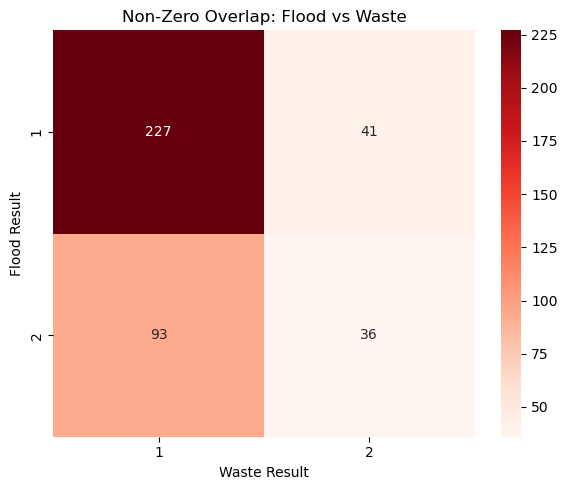

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the cross-tab matrix
overlap_matrix = pd.crosstab(df['result_flood'], df['result_waste'])

# Remove rows and columns where result is 0
filtered_matrix = overlap_matrix.loc[overlap_matrix.index != 0, overlap_matrix.columns != 0]

# Plot the filtered heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(filtered_matrix, annot=True, fmt="d", cmap="Reds", cbar=True)

plt.title("Non-Zero Overlap: Flood vs Waste")
plt.xlabel("Waste Result")
plt.ylabel("Flood Result")
plt.tight_layout()
plt.show()


In [46]:
df_active = df[(df['result_flood'] > 0) | (df['result_waste'] > 0)]
df_active

,focused_flood,latitude_flood,longitude_flood,lat_min,lat_max,lon_min,lon_max,result_flood,focused_waste,result_waste,latitude_waste,longitude_waste,has_waste,has_flood
1,0.000000,-1.116500,36.941600,-1.116940,-1.116130,36.941050,36.942050,2,0,0,-1.116500,36.941600,False,1
2,0.000000,-1.116500,36.942600,-1.116940,-1.116130,36.942040,36.943050,2,0,0,-1.116500,36.942600,False,1
17,0.000000,-1.116500,36.957500,-1.116940,-1.116130,36.957010,36.958020,1,0,0,-1.116500,36.957500,False,1
18,0.000000,-1.116500,36.958500,-1.116940,-1.116130,36.958010,36.959010,1,0,0,-1.116500,36.958500,False,1
26,0.000000,-1.116500,36.966500,-1.116940,-1.116130,36.965990,36.967000,2,0,0,-1.116500,36.966500,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110324,NaN,-1.410100,36.697600,-1.410550,-1.409740,36.697120,36.698130,1,0,0,-1.410100,36.697600,False,1
110325,NaN,-1.410100,36.768500,-1.410550,-1.409740,36.767980,36.768980,2,0,0,-1.410100,36.768500,False,1
110326,NaN,-1.411000,36.768500,-1.411360,-1.410550,36.767990,36.768990,1,0,0,-1.411000,36.768500,False,1
110329,NaN,-1.412600,36.773500,-1.412970,-1.412160,36.772990,36.774000,1,0,0,-1.412600,36.773500,False,1


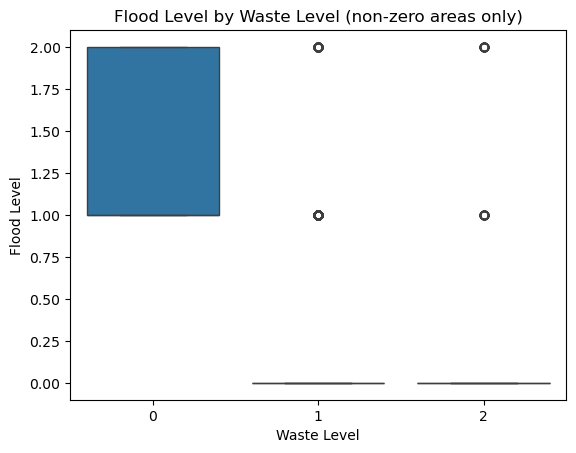

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_active, x='result_waste', y='result_flood')
plt.title("Flood Level by Waste Level (non-zero areas only)")
plt.xlabel("Waste Level")
plt.ylabel("Flood Level")
plt.show()


In [49]:
correlation_active = df_active['result_waste'].corr(df_active['result_flood'], method='spearman')
print(f"Spearman correlation (non-zero zones): {correlation_active:.3f}")

Spearman correlation (non-zero zones): -0.489


In [50]:
import statsmodels.api as sm

df_active['has_flood'] = (df_active['result_flood'] > 0).astype(int)
X = sm.add_constant(df_active['result_waste'])
y = df_active['has_flood']

model = sm.Logit(y, X).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.059974
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              has_flood   No. Observations:                27793
Model:                          Logit   Df Residuals:                    27791
Method:                           MLE   Df Model:                            1
Date:                Wed, 11 Jun 2025   Pseudo R-squ.:                  0.7766
Time:                        15:22:41   Log-Likelihood:                -1666.8
converged:                       True   LL-Null:                       -7460.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.7922      0.114     50.749      0.000       5.569       6.016
result_waste    -7.078

/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_73740/2711179364.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_active['has_flood'] = (df_active['result_flood'] > 0).astype(int)
